# Lab_06_1_Softmax_Classification

Softmax Classification(소프트맥스 클래시피케이션, 다중분류)

## 목표

- Binary Classification(바이너리 클래시피케이션, 이진분류)을 3개 클래스 분류로 확장하기
- 4개 입력 특성으로 A·B·C 클래스 중 하나를 예측하기
- `nn.Linear(4, 3)`이 데이터마다 3개의 Logit(로짓, 클래스별 원점수)을 출력하는 구조 이해하기
- Softmax(소프트맥스, 여러 점수를 확률 분포로 변환하는 함수)의 계산 결과 확인하기
- One-Hot Encoding(원핫 인코딩, 정답 클래스만 1로 표시)과 Class Index(클래스 인덱스, 정답 번호)의 차이 이해하기
- Cross Entropy(크로스 엔트로피, 다중분류 손실)의 계산 원리 확인하기
- `CrossEntropyLoss()`로 모델을 학습하고 `argmax()`로 클래스를 예측하기

**Softmax converts class logits into one probability distribution.**  
**소프트맥스는 클래스별 로짓을 하나의 확률 분포로 변환합니다.**

## 실습 흐름

```text
작은 학습 데이터 직접 입력
→ 클래스 인덱스와 원핫 벡터 확인
→ nn.Linear(4, 3)의 로짓 계산
→ Softmax 확률 확인
→ Cross Entropy 손실 확인
→ 모델 학습
→ argmax 클래스 예측
→ 정확도·혼동행렬 확인
```

이번 `Lab 06_1`은 다중분류의 원리를 확인하는 기초 실습입니다.  
실제 CSV(씨에스브이, 쉼표 구분 데이터) 불러오기와 훈련·테스트 분리는 `Lab 06_2`에서 진행합니다.

## 1. 준비

### 1.1 라이브러리 불러오기

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 같은 결과를 재현할 수 있도록 난수 고정
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


## 2. 데이터

### 2.1 작은 다중분류 데이터 직접 입력하기

- 데이터 수: 8개
- 입력 특성 수: 4개
- 클래스 수: 3개
- 클래스 번호: `0`, `1`, `2`
- 클래스 이름: `A`, `B`, `C`

입력의 각 행은 데이터 1개이며, 목표값의 각 숫자는 해당 데이터의 정답 클래스입니다.

| 클래스 인덱스 | 클래스 이름 |
|---:|---|
| `0` | A |
| `1` | B |
| `2` | C |

In [2]:
# 입력 특성 4개를 가진 데이터 8개
x_data = torch.tensor(
    [
        [1.0, 2.0, 1.0, 1.0],
        [2.0, 1.0, 3.0, 2.0],
        [3.0, 1.0, 3.0, 4.0],
        [4.0, 1.0, 5.0, 5.0],
        [1.0, 7.0, 5.0, 5.0],
        [1.0, 2.0, 5.0, 6.0],
        [1.0, 6.0, 6.0, 6.0],
        [1.0, 7.0, 7.0, 7.0],
    ],
    dtype=torch.float32,
)

# CrossEntropyLoss가 요구하는 클래스 인덱스 형식
# 클래스 0 → A, 클래스 1 → B, 클래스 2 → C
y_data = torch.tensor(
    [2, 2, 2, 1, 1, 1, 0, 0],
    dtype=torch.long,
)

class_names = ["A", "B", "C"]

print("입력 데이터:")
print(x_data)
print("\n목표 클래스 인덱스:")
print(y_data)
print("\n입력 형상:", x_data.shape)
print("목표 형상:", y_data.shape)

입력 데이터:
tensor([[1., 2., 1., 1.],
        [2., 1., 3., 2.],
        [3., 1., 3., 4.],
        [4., 1., 5., 5.],
        [1., 7., 5., 5.],
        [1., 2., 5., 6.],
        [1., 6., 6., 6.],
        [1., 7., 7., 7.]])

목표 클래스 인덱스:
tensor([2, 2, 2, 1, 1, 1, 0, 0])

입력 형상: torch.Size([8, 4])
목표 형상: torch.Size([8])


### 2.2 데이터 형상 읽기

입력 형상 `[8, 4]`의 의미:

- `8`: 데이터 수
- `4`: 데이터마다 입력 특성 4개

목표 형상 `[8]`의 의미:

- 데이터마다 정답 클래스 번호 1개
- `CrossEntropyLoss()`에는 `[8, 1]`이 아니라 `[8]` 형태의 정수형 클래스 인덱스를 전달

**For CrossEntropyLoss, targets are class indices, not one-hot vectors.**  
**CrossEntropyLoss의 정답은 원핫 벡터가 아니라 클래스 인덱스입니다.**

## 3. 실습 단계

### 3.1 클래스 인덱스를 원핫 벡터로 바꾸어 보기

3개 클래스를 원핫 벡터로 나타내면 다음과 같습니다.

| 클래스 | 클래스 인덱스 | 원핫 벡터 |
|---|---:|---|
| A | `0` | `[1, 0, 0]` |
| B | `1` | `[0, 1, 0]` |
| C | `2` | `[0, 0, 1]` |

원핫 벡터는 개념을 이해할 때 유용하지만, 이번 PyTorch(파이토치) 학습 코드에서는 클래스 인덱스를 그대로 사용합니다.

In [3]:
number_of_classes = len(class_names)

# 클래스 인덱스를 원핫 벡터로 변환하여 구조 확인
y_one_hot = F.one_hot(
    y_data,
    num_classes=number_of_classes,
).float()

print("클래스 인덱스:")
print(y_data)
print("\n원핫 벡터:")
print(y_one_hot)
print("\n원핫 벡터 형상:", y_one_hot.shape)

클래스 인덱스:
tensor([2, 2, 2, 1, 1, 1, 0, 0])

원핫 벡터:
tensor([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.]])

원핫 벡터 형상: torch.Size([8, 3])


### 3.2 로짓과 소프트맥스 확률 구분하기

모델은 클래스마다 하나의 점수를 계산합니다.

$$
Z=XW^T+b
$$

- $X$: 입력
- $W$: 클래스별 가중치
- $b$: 클래스별 편향
- $Z$: 클래스별 Logit(로짓, 소프트맥스 적용 전 원점수)

로짓은 음수나 큰 양수가 될 수 있으며 아직 확률이 아닙니다.  
Softmax Function(소프트맥스 함수)은 $K$개 로짓을 0과 1 사이의 확률로 변환합니다.

$$
P(y=k|x)=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}
$$

한 데이터에서 모든 클래스 확률의 합은 1입니다.

In [4]:
# 데이터 2개에 대한 임의의 클래스별 로짓
example_logits = torch.tensor(
    [
        [2.0, 1.0, 0.1],
        [-1.0, 0.5, 2.5],
    ],
    dtype=torch.float32,
)

# dim=1: 각 행 안의 3개 클래스 점수를 확률로 변환
example_probabilities = torch.softmax(example_logits, dim=1)

print("로짓:")
print(example_logits)
print("\n소프트맥스 확률:")
print(example_probabilities)
print("\n각 데이터의 확률 합:")
print(example_probabilities.sum(dim=1))
print("\n예측 클래스:")
print(torch.argmax(example_probabilities, dim=1))

로짓:
tensor([[ 2.0000,  1.0000,  0.1000],
        [-1.0000,  0.5000,  2.5000]])

소프트맥스 확률:
tensor([[0.6590, 0.2424, 0.0986],
        [0.0259, 0.1161, 0.8580]])

각 데이터의 확률 합:
tensor([1.0000, 1.0000])

예측 클래스:
tensor([0, 2])


### 3.3 `dim=1`의 의미 확인하기

`example_logits`의 형상은 `[2, 3]`입니다.

- `dim=0`: 같은 열에서 데이터 2개끼리 계산
- `dim=1`: 같은 행에서 클래스 3개끼리 계산

다중분류에서는 데이터마다 클래스 확률의 합이 1이어야 하므로 `dim=1`을 사용합니다.

In [5]:
probabilities_dim_0 = torch.softmax(example_logits, dim=0)
probabilities_dim_1 = torch.softmax(example_logits, dim=1)

print("dim=0 적용 후 열별 합:")
print(probabilities_dim_0.sum(dim=0))

print("\ndim=1 적용 후 행별 합:")
print(probabilities_dim_1.sum(dim=1))

dim=0 적용 후 열별 합:
tensor([1., 1., 1.])

dim=1 적용 후 행별 합:
tensor([1.0000, 1.0000])


### 3.4 교차엔트로피 손실 직접 계산하기

정답 클래스의 예측 확률이 $p_{correct}$일 때 데이터 1개의 손실은 다음과 같습니다.

$$
Loss=-\log(p_{correct})
$$

- 정답 클래스 확률이 1에 가까움 → 손실이 작음
- 정답 클래스 확률이 0에 가까움 → 손실이 큼
- 틀린 클래스를 강하게 확신할수록 큰 손실

전체 손실은 각 데이터 손실의 평균입니다.

In [6]:
example_targets = torch.tensor([0, 2], dtype=torch.long)

# 1단계: 로짓을 소프트맥스 확률로 변환
manual_probabilities = torch.softmax(example_logits, dim=1)

# 2단계: 각 데이터의 정답 클래스 확률 선택
row_indices = torch.arange(len(example_targets))
correct_class_probabilities = manual_probabilities[
    row_indices,
    example_targets,
]

# 3단계: -log(정답 클래스 확률)의 평균 계산
manual_cross_entropy = -torch.log(
    correct_class_probabilities
).mean()

print("정답 클래스 확률:", correct_class_probabilities)
print("데이터별 손실:", -torch.log(correct_class_probabilities))
print("평균 교차엔트로피:", manual_cross_entropy.item())

정답 클래스 확률: tensor([0.6590, 0.8580])
데이터별 손실: tensor([0.4170, 0.1532])
평균 교차엔트로피: 0.28510409593582153


### 3.5 PyTorch 교차엔트로피와 비교하기

`nn.CrossEntropyLoss()`는 다음 계산을 내부에서 한 번에 처리합니다.

```text
LogSoftmax(로그 소프트맥스)
→ Negative Log Likelihood(네거티브 로그 라이클리후드, 음의 로그우도)
```

따라서 학습할 때는 모델의 로짓에 `softmax()`를 먼저 적용하지 않습니다.

```python
# 권장
loss = nn.CrossEntropyLoss()(logits, targets)

# 사용하지 않음
loss = nn.CrossEntropyLoss()(torch.softmax(logits, dim=1), targets)
```

In [7]:
cross_entropy_function = nn.CrossEntropyLoss()
pytorch_cross_entropy = cross_entropy_function(
    example_logits,
    example_targets,
)

print(f"직접 계산한 교차엔트로피: {manual_cross_entropy.item():.6f}")
print(f"PyTorch CrossEntropyLoss: {pytorch_cross_entropy.item():.6f}")
print(
    "두 결과의 차이:",
    abs(
        manual_cross_entropy.item()
        - pytorch_cross_entropy.item()
    ),
)

직접 계산한 교차엔트로피: 0.285104
PyTorch CrossEntropyLoss: 0.285104
두 결과의 차이: 0.0


### 3.6 다중분류 모델 정의하기

`nn.Linear(4, 3)`의 의미:

- 입력 특성: 4개
- 출력 로짓: 3개
- 출력 로짓은 각각 A·B·C 클래스의 점수

$$
[x_1,x_2,x_3,x_4]
\rightarrow
[z_A,z_B,z_C]
$$

모델의 `forward()`에서는 소프트맥스를 적용하지 않고 로짓을 그대로 반환합니다.

In [8]:
class SoftmaxClassificationModel(nn.Module):
    def __init__(self, number_of_features, number_of_classes):
        super().__init__()

        # 입력 특성 4개 → 클래스별 로짓 3개
        self.linear = nn.Linear(
            number_of_features,
            number_of_classes,
        )

    def forward(self, x):
        # CrossEntropyLoss에 전달할 로짓 반환
        return self.linear(x)


model = SoftmaxClassificationModel(
    number_of_features=x_data.shape[1],
    number_of_classes=number_of_classes,
)

# 시작 조건을 일정하게 설정
nn.init.zeros_(model.linear.weight)
nn.init.zeros_(model.linear.bias)

print(model)
print("가중치 형상:", model.linear.weight.shape)
print("편향 형상:", model.linear.bias.shape)

initial_logits = model(x_data)
print("모델 출력 형상:", initial_logits.shape)
print("첫 데이터의 초기 로짓:", initial_logits[0])

SoftmaxClassificationModel(
  (linear): Linear(in_features=4, out_features=3, bias=True)
)
가중치 형상: torch.Size([3, 4])
편향 형상: torch.Size([3])
모델 출력 형상: torch.Size([8, 3])
첫 데이터의 초기 로짓: tensor([0., 0., 0.], grad_fn=<SelectBackward0>)


### 3.7 손실함수와 최적화 도구 정의하기

- 손실함수: `nn.CrossEntropyLoss()`
- 최적화 도구: SGD(에스지디, 확률적 경사하강법)
- 학습 대상: 가중치 12개와 편향 3개
- 학습률: `0.1`

In [9]:
# 로짓과 클래스 인덱스로 교차엔트로피 계산
loss_function = nn.CrossEntropyLoss()

# 경사하강법으로 가중치와 편향 갱신
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
)

### 3.8 모델 학습하기

학습 순서:

1. 입력으로 클래스별 로짓 계산
2. 로짓과 정답 클래스 인덱스로 손실 계산
3. 이전 기울기 초기화
4. `backward()`로 기울기 계산
5. `step()`으로 가중치와 편향 갱신

In [10]:
number_of_epochs = 3000
loss_history = []

model.train()

for epoch in range(number_of_epochs):
    # 순전파: 데이터마다 클래스 로짓 3개 계산
    logits = model(x_data)

    # CrossEntropyLoss가 내부에서 소프트맥스 관련 계산 수행
    loss = loss_function(logits, y_data)

    # 기울기 초기화 → 역전파 → 가중치 갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        with torch.no_grad():
            predictions = torch.argmax(logits, dim=1)
            accuracy = (predictions == y_data).float().mean()

        print(
            f"Epoch {epoch + 1:4d} | "
            f"Loss {loss.item():.6f} | "
            f"Accuracy {accuracy.item():.4f}"
        )

Epoch  500 | Loss 0.426139 | Accuracy 0.7500
Epoch 1000 | Loss 0.248214 | Accuracy 1.0000
Epoch 1500 | Loss 0.193196 | Accuracy 1.0000
Epoch 2000 | Loss 0.158878 | Accuracy 1.0000
Epoch 2500 | Loss 0.134627 | Accuracy 1.0000
Epoch 3000 | Loss 0.116635 | Accuracy 1.0000


## 4. 결과 확인

### 4.1 손실 변화 확인하기

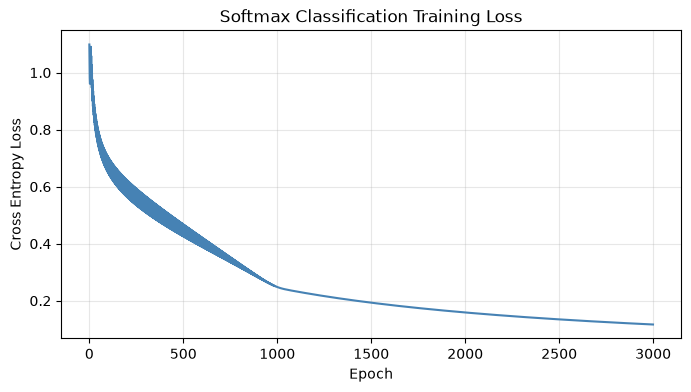

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Softmax Classification Training Loss")
plt.grid(alpha=0.3)
plt.show()

### 4.2 로짓·확률·예측 클래스 확인하기

학습이 끝난 뒤 결과를 다음 순서로 해석합니다.

```text
모델 출력 로짓
→ softmax 확률
→ argmax로 가장 큰 확률의 위치 선택
→ 예측 클래스
```

`argmax(dim=1)`은 각 데이터의 클래스 확률 중 가장 큰 값의 인덱스를 반환합니다.

In [12]:
model.eval()

with torch.no_grad():
    trained_logits = model(x_data)
    trained_probabilities = torch.softmax(
        trained_logits,
        dim=1,
    )
    predicted_classes = torch.argmax(
        trained_logits,
        dim=1,
    )
    accuracy = (
        predicted_classes == y_data
    ).float().mean()

print(f"학습 데이터 정확도: {accuracy.item():.4f}\n")
print("번호 | 클래스별 확률 [A, B, C]        | 예측 | 실제")

for index, (probabilities, predicted, actual) in enumerate(
    zip(trained_probabilities, predicted_classes, y_data)
):
    rounded_probabilities = [
        round(value, 4)
        for value in probabilities.tolist()
    ]
    print(
        f"{index:>4d} | "
        f"{str(rounded_probabilities):<31} | "
        f"{class_names[predicted.item()]:>4s} | "
        f"{class_names[actual.item()]:>4s}"
    )

학습 데이터 정확도: 1.0000

번호 | 클래스별 확률 [A, B, C]        | 예측 | 실제
   0 | [0.0, 0.0004, 0.9996]           |    C |    C
   1 | [0.0008, 0.06, 0.9391]          |    C |    C
   2 | [0.0, 0.1219, 0.8781]           |    C |    C
   3 | [0.0, 0.8892, 0.1108]           |    B |    B
   4 | [0.1976, 0.7936, 0.0088]        |    B |    B
   5 | [0.1043, 0.8957, 0.0]           |    B |    B
   6 | [0.7949, 0.2051, 0.0]           |    A |    A
   7 | [0.9499, 0.0501, 0.0]           |    A |    A


### 4.3 클래스별 확률 시각화하기

각 데이터의 A·B·C 확률을 막대그래프로 비교합니다.  
막대가 가장 높은 클래스가 최종 예측 클래스입니다.

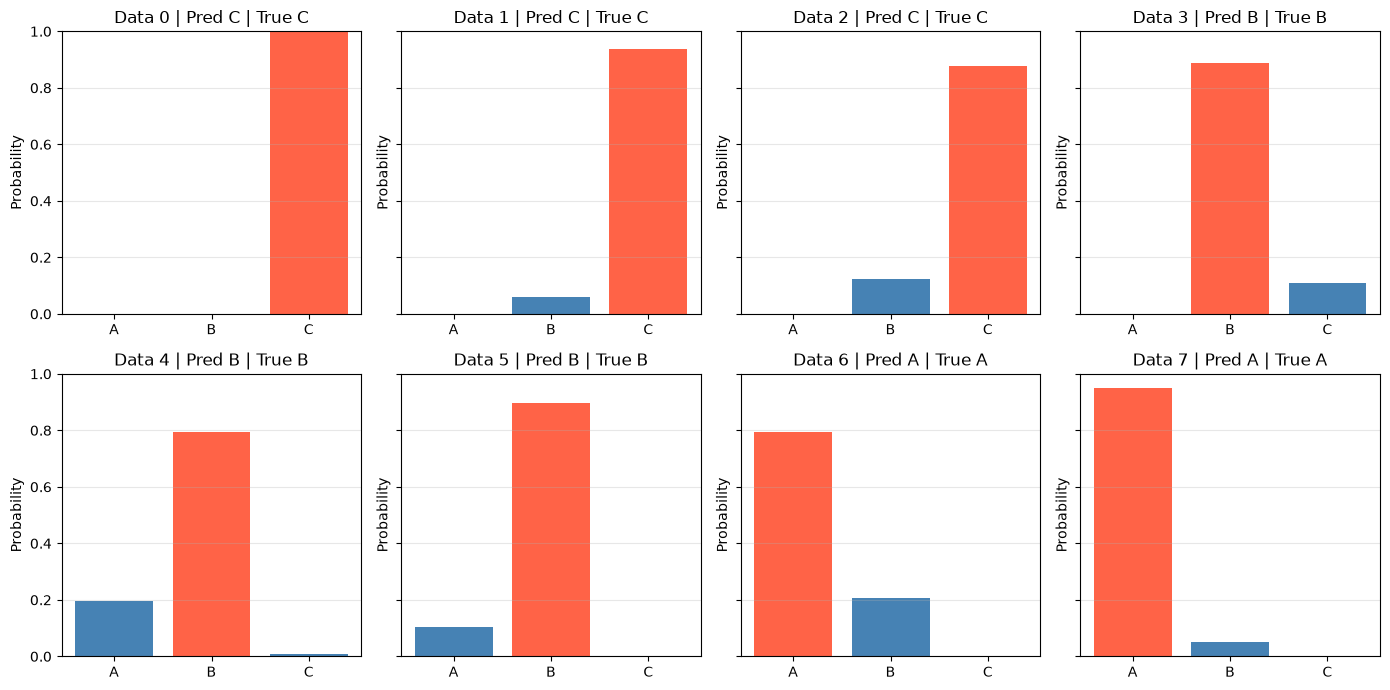

In [13]:
figure, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
    sharey=True,
)

for index, axis in enumerate(axes.flat):
    probabilities = trained_probabilities[index].numpy()
    predicted_index = predicted_classes[index].item()
    actual_index = y_data[index].item()

    colors = [
        "tomato" if class_index == predicted_index else "steelblue"
        for class_index in range(number_of_classes)
    ]

    axis.bar(class_names, probabilities, color=colors)
    axis.set_ylim(0, 1)
    axis.set_title(
        f"Data {index} | "
        f"Pred {class_names[predicted_index]} | "
        f"True {class_names[actual_index]}"
    )
    axis.set_ylabel("Probability")
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 다중분류 혼동행렬 확인하기

행은 실제 클래스, 열은 예측 클래스입니다.

- 대각선: 올바르게 분류한 개수
- 대각선 밖: 다른 클래스로 잘못 분류한 개수

이번 데이터는 학습용 소규모 데이터이므로 혼동행렬은 다중분류 평가 구조를 익히는 용도입니다.

혼동행렬:
tensor([[2, 0, 0],
        [0, 3, 0],
        [0, 0, 3]])


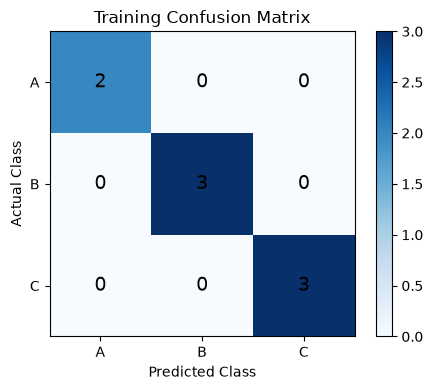

In [14]:
confusion_matrix = torch.zeros(
    number_of_classes,
    number_of_classes,
    dtype=torch.int64,
)

for actual, predicted in zip(y_data, predicted_classes):
    confusion_matrix[actual, predicted] += 1

print("혼동행렬:")
print(confusion_matrix)

plt.figure(figsize=(5, 4))
plt.imshow(confusion_matrix.numpy(), cmap="Blues")
plt.xticks(range(number_of_classes), class_names)
plt.yticks(range(number_of_classes), class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Training Confusion Matrix")

for row in range(number_of_classes):
    for column in range(number_of_classes):
        plt.text(
            column,
            row,
            int(confusion_matrix[row, column]),
            ha="center",
            va="center",
            fontsize=14,
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## 5. 확인 실습

### 5.1 새로운 데이터 예측하기

학습 데이터와 같은 형식으로 입력 특성 4개를 가진 새로운 데이터를 넣습니다.

- 로짓 3개 출력
- 소프트맥스로 A·B·C 확률 계산
- 가장 큰 확률의 클래스 선택

In [15]:
new_x = torch.tensor(
    [
        [1.0, 5.0, 5.0, 5.0],
        [3.0, 2.0, 4.0, 4.0],
        [2.0, 1.0, 2.0, 2.0],
    ],
    dtype=torch.float32,
)

model.eval()

with torch.no_grad():
    new_logits = model(new_x)
    new_probabilities = torch.softmax(new_logits, dim=1)
    new_predictions = torch.argmax(new_logits, dim=1)

print("입력                  | 확률 [A, B, C]                 | 예측")

for inputs, probabilities, predicted in zip(
    new_x,
    new_probabilities,
    new_predictions,
):
    rounded_probabilities = [
        round(value, 4)
        for value in probabilities.tolist()
    ]
    print(
        f"{str(inputs.tolist()):<21} | "
        f"{str(rounded_probabilities):<32} | "
        f"{class_names[predicted.item()]}"
    )

입력                  | 확률 [A, B, C]                 | 예측
[1.0, 5.0, 5.0, 5.0]  | [0.4417, 0.5576, 0.0007]         | B
[3.0, 2.0, 4.0, 4.0]  | [0.0, 0.3802, 0.6198]            | C
[2.0, 1.0, 2.0, 2.0]  | [0.0, 0.0048, 0.9952]            | C


### 5.2 실행 확인

아래 셀에서 오류가 없으면 `Lab 06_1`이 정상적으로 완료된 것입니다.

In [16]:
assert x_data.shape == torch.Size([8, 4])
assert y_data.shape == torch.Size([8])
assert y_data.dtype == torch.long
assert y_one_hot.shape == torch.Size([8, 3])
assert trained_logits.shape == torch.Size([8, 3])
assert trained_probabilities.shape == torch.Size([8, 3])
assert torch.allclose(
    trained_probabilities.sum(dim=1),
    torch.ones(8),
    atol=1e-6,
)
assert abs(
    manual_cross_entropy.item()
    - pytorch_cross_entropy.item()
) < 1e-6
assert loss_history[-1] < loss_history[0]
assert accuracy.item() == 1.0
assert torch.equal(predicted_classes, y_data)

print("Lab 06_1 실행 확인 완료")

Lab 06_1 실행 확인 완료


## 6. 핵심 정리

- 문제: 입력 특성 4개로 A·B·C 중 하나를 예측하는 다중분류
- 입력 형상: `[8, 4]`
- 정답 형상: `[8]`
- 정답 자료형: `torch.long`
- 선형계층: `nn.Linear(4, 3)`
- 모델 출력: 클래스별 로짓 3개
- 확률 확인: `torch.softmax(logits, dim=1)`
- 손실함수: `nn.CrossEntropyLoss()`
- 학습 시 모델에 소프트맥스를 별도로 넣지 않음
- 클래스 예측: `torch.argmax(logits, dim=1)`
- 원핫 벡터: 개념 확인용
- 클래스 인덱스: `CrossEntropyLoss()` 학습용
- 이번 정확도: 학습 데이터 적합도 확인
- 일반화 성능: 실제 데이터를 훈련·테스트로 나누어 평가해야 함

